# Clustering Credit Card Users

In this notebook, our main task is to cluster credit card users into different groups and see if we can find any meaningful patterns. We will use Principal Component Analysis **(PCA)** to reduce the dimension of the feature space and then use the **K-means** algorithm to find clusters.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [43]:
# df = pd.read_csv("temp/CC_GENERAL.csv")
df = pd.read_csv("data_CC_GENERAL.csv")

df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [44]:
df.shape

(8950, 18)

## Preprocessing the Dataset

### First Look

There are 8950 rows and 18 attributes in each row. Since this is an unsupervised learning problem, we do not have a response variable. 

Moreover, note that **CUST_ID** can be removed as its sole purpose is to be a primary key.

After important attributes have been identified through PCA, we will explain them in detail. We do not need to breakdown every single attribute because we will not be using every single attribute.

In [45]:
df = df.drop("CUST_ID", axis=1)

### Missing Values

Next, we look for missing values and handle them accordingly.

In [46]:
df.isna().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

## Domain experience can be helpful
We see that there is one NULL value for **CREDIT_LIMIT** and 313 NULL values for **MINIMUM_PAYMENTS**. Before we fill in the NULL values, we need to understand what these attributes are doing.

1. When **MINIMUM_PAYMENTS** is null, we will **assume** that no minimum payment was made. This means we can convert all the NULL values in **MINIMUM_PAYMENTS** to 0.  

2. When **MINIMUM_PAYMENTS** is NULL, the most rational assumption is that there is no credit limit for that particular customer. Once again, we can set it to 0.

In [47]:
df = df.fillna(0)

In [48]:
df.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

### Standardize And Normalize

Before we perform PCA, we standardize and normalize the data because clustering algorithm is based on distance between data points: **column with large magnitudes could could hijack columns with low values**.  

In [49]:
# Standardize
scaler = StandardScaler() 
df_scaled = scaler.fit_transform(df) # Centers the data to a mean of 0 and scales it to a variance of 1.

# Normalize
df_norm = normalize(df_scaled) # Scales each row (sample) to have a unit norm (a length of 1).

In [50]:
df_norm

array([[-0.31218583, -0.10638121, -0.18121531, ..., -0.12679949,
        -0.22414201,  0.15382607],
       [ 0.21990347,  0.03753485, -0.13120867, ...,  0.0285141 ,
         0.06545091,  0.10078606],
       [ 0.1266942 ,  0.14679727, -0.03050742, ..., -0.02507315,
        -0.14891306,  0.10219731],
       ...,
       [-0.1570076 , -0.03933189, -0.08524007, ..., -0.06822998,
         0.0698096 , -0.87426728],
       [-0.15435222, -0.03841886, -0.09726098, ..., -0.06901049,
         0.06818909, -0.85397255],
       [-0.11522902, -0.17891523,  0.00848172, ..., -0.06424564,
        -0.10576555, -0.82969457]])

## PCA

We use PCA to reduce the dimensionality of our data. Essentially, we are reducing our 17 dimensional data to n (<17) dimensions - where n is the number of components. Since clustering methods suffer from the "curse of dimensionality," we make our data less complex.

In [51]:
pca = PCA()
pca.fit(df_norm)

PCA()

[0.29044997 0.47452947 0.58490237 0.68505818 0.75571567 0.8127604
 0.86368729 0.89770753 0.92447857 0.94517107 0.95813186 0.97045662
 0.9810481  0.99022739 0.99688251 0.9999988  1.        ]


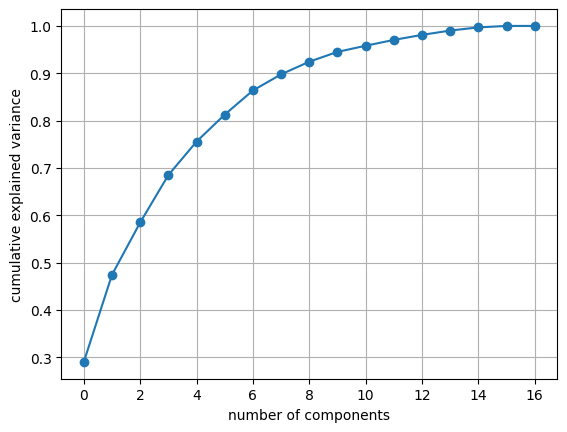

In [52]:
# Lets see how much of variance is explained by PC

print(np.cumsum(pca.explained_variance_ratio_))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.grid()
plt.show()

### PCA Summary

The above plot shows us the total explained variance for the number of principal components we use. 

For our case, we will use **2 principal components**: The first 2 principal components explain **47.5%** of the variation in data. While 4 or 5 components would be ideal in terms of explaining variance, we pick 2 so that we can visualize the clustering as well. 

In [53]:
n_components=2

pca_final = PCA(n_components=n_components)
pca_final.fit(df_norm)
pca_df = pca_final.fit_transform(df_norm)

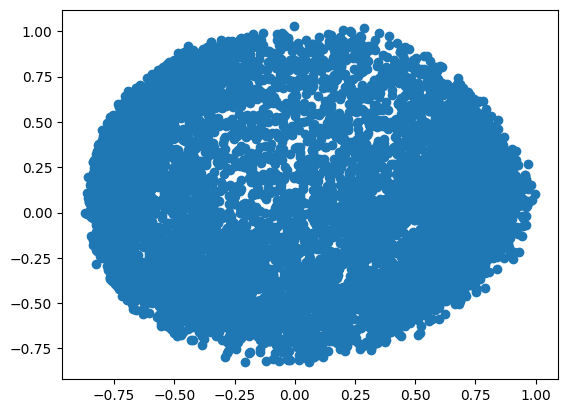

In [54]:
plt.scatter(pca_df[:,0], # x-axis here
            pca_df[:,1]) # y-axis here

### Visualize Reduced Data

When we look at the data, there are no immediate patterns jumping out at us. Next, we try interpret these principal components.

In [57]:

# this is Incorrect

# for i in np.arange(n_components):
#     index =  np.argmax(np.absolute(pca_final.get_covariance()[i]))
#     max_cov = pca_final.get_covariance()[i][index]
#     column = df.columns[index]
#     print("Principal Component", i+1, "maximum covariance(i.e.PC is most influenced by ) :", "{:.2f}".format(max_cov), "from column", column)

In [58]:
# Lets the most influential features of the components

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=df.columns,
    columns=['PC1', 'PC2']
)

print("Sorted by PC1:\n", loadings.sort_values('PC1', key=np.abs, ascending=False).head())
print("------------------------------------------")
print("Sorted by PC2:\n", loadings.sort_values('PC2', key=np.abs, ascending=False).head())

Sorted by PC1:
                                        PC1       PC2
PURCHASES_FREQUENCY               0.575715  0.035487
PURCHASES_INSTALLMENTS_FREQUENCY  0.523175 -0.026218
PURCHASES_TRX                     0.292158  0.142869
ONEOFF_PURCHASES_FREQUENCY        0.246774  0.227292
INSTALLMENTS_PURCHASES            0.240040  0.077405
------------------------------------------
Sorted by PC2:
                              PC1       PC2
BALANCE                -0.075603  0.445143
CASH_ADVANCE_FREQUENCY -0.208700  0.438931
CREDIT_LIMIT            0.097338  0.362772
CASH_ADVANCE           -0.112808  0.336652
CASH_ADVANCE_TRX       -0.124153  0.332692


### Interpret PCA

Since the principal components are linear combinations of the attributes, we are basically trying to identify which variables  affect the principal components the most. 


### PC1
For the first principal component (PC1), the largest loadings correspond to:

- PURCHASES_FREQUENCY
- PURCHASES_INSTALLMENTS_FREQUENCY
- PURCHASES_TRX

This indicates that PC1 measures **overall purchase activity**. Customers with high PC1 values tend to use their credit cards frequently and make more purchase transactions.


### PC2
For the second principal component (PC2), the largest loadings correspond to:

- BALANCE
- CASH_ADVANCE_FREQUENCY
- CREDIT_LIMIT
- CASH_ADVANCE

This indicates that PC2 measures **debt and cash-advance behavior**. Customers with high PC2 values tend to carry larger balances, have higher credit limits, and rely more on cash advances.

## Kmeans Clustering

### Using Elbow method to find right number of clusters

Recall that in order to use the Kmeans algorithm, we have to provide the number of clusters that we are trying to segment our data into. Since we do not know what is ideal, let us try a range of 2-11 clusters. We will look at metric plots to determine what works best.

In [19]:
sse = {}
n_clust = np.arange(2,11)

for i in n_clust:
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(pca_df)
    sse[i] = kmeans.inertia_

print(sse)

{2: 2121.330903703598, 3: 1316.8996814437528, 4: 928.3916335232578, 5: 724.9898332992676, 6: 631.6211042196568, 7: 529.7816695579899, 8: 456.1843006302969, 9: 395.61759663827775, 10: 355.5137322424484}


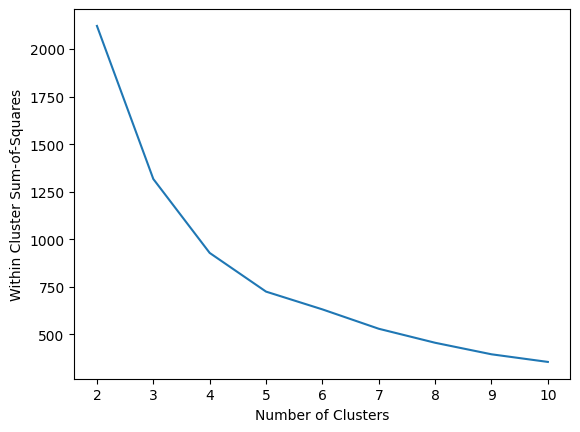

In [20]:
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of Clusters")
plt.ylabel("Within Cluster Sum-of-Squares")
plt.show()

### Summary of Kmeans

In the above plot, we are looking for an "elbow." The elbow tells us the point where increasing the number of variables does not yield a significant decrease in inertia. The inertia here is referring to within cluster sum of squares. It tells how compact a given cluster is. From the above plot, **k=3 clusters seem sufficient**. Although using 10 clusters gives us the least inertia, it will be very difficult to interpret and may not have significant meaning. 

In [21]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(pca_df)

KMeans(n_clusters=3, random_state=0)

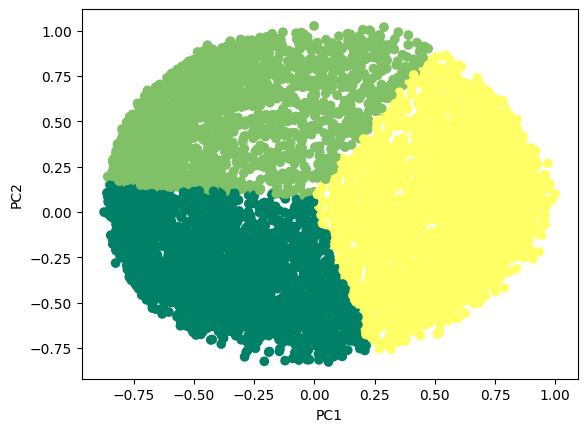

In [22]:
plt.scatter(pca_df[:,0],
            pca_df[:,1],
            c = KMeans(n_clusters = 3).fit_predict(pca_df),
            cmap = plt.cm.summer)
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show() 

### (OPTIONAL) Visualize Clusters

The 3 clusters are distinctly separated. Let us expand the above plot to include a decision boundary.

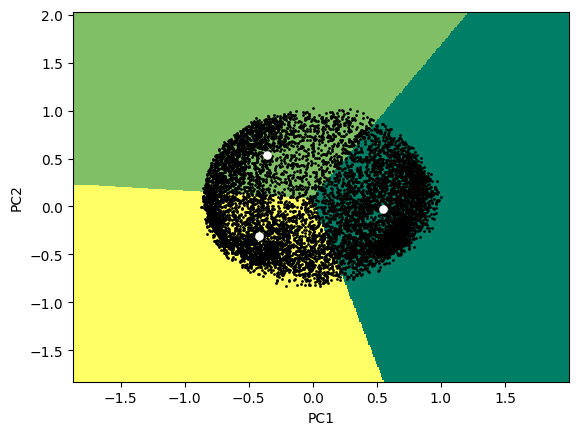

In [59]:
h = .01

x_min, x_max = pca_df[:,0].min() - 1, pca_df[:,0].max() + 1
y_min, y_max = pca_df[:,1].min() - 1, pca_df[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = kmeans.predict(np.array(list(zip(xx.ravel(), yy.ravel()))))

Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.summer,
           aspect='auto', origin='lower')

plt.plot(pca_df[:,0], pca_df[:,1], 'k.', markersize=2)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='o', s=10, linewidths=3,
            color='w', zorder=10)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()


The decision boundary is much clearer now, and we also see the center of the 3 identified clusters. Our final objective is to try and make sense of these clusters.

In [25]:
# Print the centroid
for i in np.arange(len(centroids)):
    print("Center of Cluster", i+1, ":", centroids[i])

Center of Cluster 1 : [ 0.54693536 -0.02850423]
Center of Cluster 2 : [-0.3539088   0.54131863]
Center of Cluster 3 : [-0.41823865 -0.31230264]


## Interpreting the KMeans Cluster Centroids

The cluster centroids are expressed in the two-dimensional PCA space:

* **PC1 = Purchase Activity**
* **PC2 = Debt and Cash Advance Usage**

So each centroid has the form:

```text
[PC1 score, PC2 score]
```

A positive score means the cluster is above the dataset average on that dimension; a negative score means it is below average.

---

## Cluster Centroids

|   Cluster |    PC1 |    PC2 |
| --------: | -----: | -----: |
| Cluster 1 |  0.547 | -0.029 |
| Cluster 2 | -0.354 |  0.541 |
| Cluster 3 | -0.418 | -0.312 |

---

# Cluster 1: Active Purchasers

**Centroid:** `(0.547, -0.029)`

### Interpretation

* Highest PC1 score.
* PC2 is near zero (average debt behavior).

### Characteristics

Compared with the other clusters, these customers:

* Use their credit cards most frequently.
* Make more purchase transactions.
* Have average balances and cash-advance behavior.

### Business Meaning

These are highly engaged customers who actively use their cards for everyday spending.

### Suggested Segment Name

**Active Everyday Spenders**

---

# Cluster 2: Credit-Dependent Customers

**Centroid:** `(-0.354, 0.541)`

### Interpretation

* Lower-than-average purchase activity.
* Highest debt and cash-advance usage.

### Characteristics

Compared with the other clusters, these customers:

* Use their cards less frequently for purchases.
* Carry higher balances.
* Use cash advances more often.
* Tend to have higher credit limits.

### Business Meaning

These customers rely more on credit and cash advances and may represent a higher-risk segment.

### Suggested Segment Name

**Debt-Oriented Customers**

---

# Cluster 3: Dormant Customers

**Centroid:** `(-0.418, -0.312)`

### Interpretation

* Low purchase activity.
* Low debt and cash-advance usage.

### Characteristics

Compared with the other clusters, these customers:

* Rarely use their credit cards.
* Maintain small balances.
* Use cash advances infrequently.

### Business Meaning

These customers are minimally engaged and may be dormant.

### Suggested Segment Name

**Low-Activity Customers**

---



# Final Segment Summary

| Cluster   | Segment Name             | Key Behavior                                     |
| --------- | ------------------------ | ------------------------------------------------ |
| Cluster 1 | Active Everyday Spenders | Frequent purchases, average debt                 |
| Cluster 2 | Debt-Oriented Customers  | Lower purchases, high balances and cash advances |
| Cluster 3 | Low-Activity Customers   | Low purchases and low debt                       |



# STOP